In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from tqdm import tqdm

# Adjust these imports if your modules are in a different spot
from modules.dna_tokenizer import DNATokenizer
from modules.custom_bert import DNABertForMaskedLM

# --- CONFIGURATION ---
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
BASE_DIR = os.getcwd()
MOTIFS_FILE = os.path.join(BASE_DIR, "../data/simulated/motifs.txt")

# Models
MODEL_BASE_PATH = os.path.join(BASE_DIR, "../model/Bear_baseline_100k_1e-5")
MODEL_DEL_PATH = os.path.join(BASE_DIR, "../model/Bear_deletion_100k_1e-5")

# Datasets - FAULTY (Non-10bp distances)
DATA_BASE_FAULTY = os.path.join(BASE_DIR, "../data/faulty_baseline.parquet")
DATA_DEL_FAULTY = os.path.join(BASE_DIR, "../data/faulty_deletions.parquet")

# Datasets - PROPER (Biological 10bp distances)
DATA_BASE_PROPER = os.path.join(BASE_DIR, "../data/simulated/baseline_test.parquet")
DATA_DEL_PROPER = os.path.join(BASE_DIR, "../data/simulated/test.parquet")

BATCH_SIZE = 32
print(f"Device: {DEVICE}")

Device: mps


In [2]:
def load_motifs(path):
    """Reads Motif A and Motif B from the text file."""
    print(f"Reading motifs from: {path}")
    with open(path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    if len(lines) < 2:
        raise ValueError("motifs.txt must contain at least two lines (Motif A and Motif B)")

    motif_a = lines[0]
    motif_b = lines[1]
    print(f"  > Motif A: {motif_a}")
    print(f"  > Motif B: {motif_b}")
    return motif_a, motif_b

def load_model(path):
    print(f"Loading from: {path}")
    try:
        tokenizer = DNATokenizer.from_pretrained(path, local_files_only=True)
    except:
        tokenizer = DNATokenizer(vocab_file=os.path.join(path, "vocab.txt"))

    model = DNABertForMaskedLM.from_pretrained(path, local_files_only=True)
    model.to(DEVICE)
    model.eval()
    return model, tokenizer

def calculate_motif_surprise(model, tokenizer, df, model_name, dataset_type):
    """
    Calculates Cross Entropy Loss specifically on Motif B tokens.
    USES CENTER MASKING: Hints the first/last token of the motif to see if
    the model can fill in the middle based on distance from Motif A.
    """
    surprises = []
    distances = []

    # 1. Basic Filter: Motifs must exist (indices != -1)
    valid_df = df[(df['motif_A_end'] != -1) & (df['motif_B_start'] != -1)].copy()

    # 2. Strict Label Filter for Proper Data:
    if "labels" in valid_df.columns:
        valid_df = valid_df[valid_df["labels"].isin(["both", "faulty"])].reset_index(drop=True)

    print(f"[{model_name} - {dataset_type}] Calculating surprise on {len(valid_df)} sequences...")

    for i in tqdm(range(0, len(valid_df), BATCH_SIZE)):
        batch = valid_df.iloc[i : i + BATCH_SIZE]
        seqs = batch['sequences'].tolist()

        encoded = tokenizer(seqs, return_tensors="pt", padding=True, truncation=True, max_length=512)
        input_ids = encoded["input_ids"].to(DEVICE)
        attention_mask = encoded["attention_mask"].to(DEVICE)
        labels = input_ids.clone()

        target_mask = torch.zeros_like(input_ids, dtype=torch.bool)
        current_distances = []

        for b_idx in range(len(batch)):
            row = batch.iloc[b_idx]

            # Get Motif B coordinates (adjusted for [CLS] token if necessary)
            m_start = int(row['motif_B_start']) + 1
            m_end = int(row['motif_B_end']) + 1
            motif_len = m_end - m_start

            # --- CENTER MASKING LOGIC ---
            # If motif is > 2 tokens, keep the first and last visible (mask the middle).
            # If motif is <= 2 tokens, we have to mask the whole thing.
            if motif_len > 2:
                mask_start = m_start + 1
                mask_end = m_end - 1
            else:
                mask_start = m_start
                mask_end = m_end

            # Boundary check
            if m_end <= input_ids.shape[1]:
                # Apply mask to the calculated center range
                target_mask[b_idx, mask_start:mask_end] = True
                input_ids[b_idx, mask_start:mask_end] = tokenizer.mask_token_id

                # --- DISTANCE CALCULATION (Restored) ---
                dist = int(row['motif_B_start']) - int(row['motif_A_end'])
                current_distances.append(dist)
            else:
                # Sequence was truncated, mark as invalid
                current_distances.append(-1)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
            logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
        active_loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
        active_loss = active_loss.view(labels.size())

        for b_idx in range(len(batch)):
            if current_distances[b_idx] == -1: continue

            # Only look at the loss for the tokens we actually masked
            motif_losses = active_loss[b_idx, target_mask[b_idx]]

            # Check if we successfully masked anything (e.g., motif_len might be 0 in bad data)
            if len(motif_losses) > 0:
                surprises.append(motif_losses.mean().item())
                distances.append(current_distances[b_idx])

    return pd.DataFrame({
        "Model": model_name,
        "Dataset": dataset_type,
        "Distance": distances,
        "Surprise": surprises
    })

Loading from: /Users/selin/PycharmProjects/InsDelGLM/notebooks/../model/Bear_baseline_100k_1e-5
[Baseline - Faulty] Calculating surprise on 10000 sequences...


100%|██████████| 313/313 [00:41<00:00,  7.54it/s]


[Baseline - Proper] Calculating surprise on 3831 sequences...


100%|██████████| 120/120 [00:15<00:00,  7.61it/s]


Loading from: /Users/selin/PycharmProjects/InsDelGLM/notebooks/../model/Bear_deletion_100k_1e-5
[Deletion - Faulty] Calculating surprise on 5352 sequences...


100%|██████████| 168/168 [00:22<00:00,  7.57it/s]


[Deletion - Proper] Calculating surprise on 3831 sequences...


100%|██████████| 120/120 [00:16<00:00,  7.35it/s]


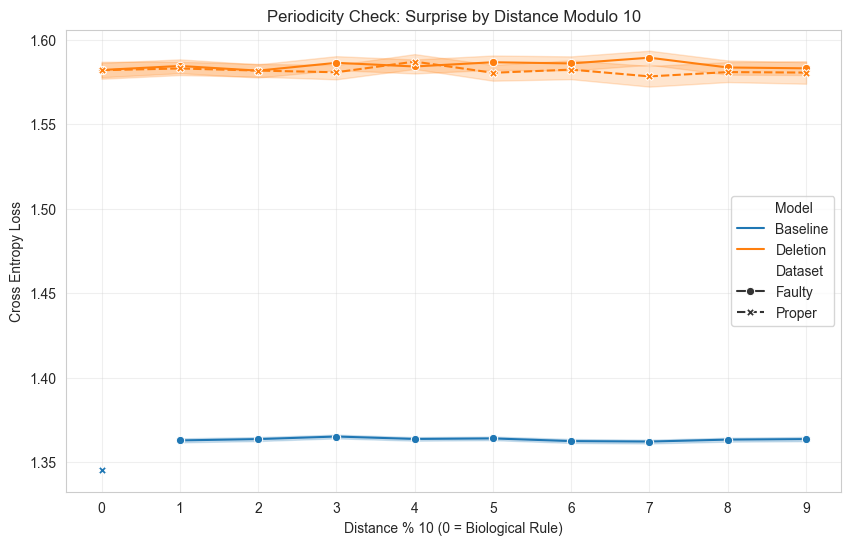

In [3]:
all_results_list = []

# --- 1. BASELINE MODEL ---
model_base, tok_base = load_model(MODEL_BASE_PATH)

# A. Faulty Data
df_base_faulty = pd.read_parquet(DATA_BASE_FAULTY)
all_results_list.append(calculate_motif_surprise(model_base, tok_base, df_base_faulty, "Baseline", "Faulty"))

# B. Proper Data
df_base_proper = pd.read_parquet(DATA_BASE_PROPER)
all_results_list.append(calculate_motif_surprise(model_base, tok_base, df_base_proper, "Baseline", "Proper"))

# Cleanup Baseline
del model_base, tok_base
torch.cuda.empty_cache()


# --- 2. DELETION MODEL ---
model_del, tok_del = load_model(MODEL_DEL_PATH)

# A. Faulty Data
df_del_faulty = pd.read_parquet(DATA_DEL_FAULTY)
all_results_list.append(calculate_motif_surprise(model_del, tok_del, df_del_faulty, "Deletion", "Faulty"))

# B. Proper Data
df_del_proper = pd.read_parquet(DATA_DEL_PROPER)
all_results_list.append(calculate_motif_surprise(model_del, tok_del, df_del_proper, "Deletion", "Proper"))

# Cleanup Deletion
del model_del, tok_del
torch.cuda.empty_cache()


# --- 3. PLOTTING ---
final_df = pd.concat(all_results_list)
# Create the modulo column
final_df['Remainder'] = final_df['Distance'] % 10

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=final_df,
    x="Remainder",
    y="Surprise",
    hue="Model",
    style="Dataset", # Optional, but might clutter since Proper is always 0
    err_style="band", # Important: shows if the variance is high
    markers=True
)

plt.title("Periodicity Check: Surprise by Distance Modulo 10")
plt.xlabel("Distance % 10 (0 = Biological Rule)")
plt.ylabel("Cross Entropy Loss")
plt.xticks(range(0, 10)) # Force integers 0-9
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
def scan_motif_surprise(model, tokenizer, sequence, motif_a_end, motif_b_seq, max_scan_dist=120):
    """
    Experimental Method:
    Takes a SINGLE sequence containing Motif A.
    It slides a mask across the sequence downstream of Motif A.
    At every position, it calculates the loss assuming the hidden content is 'motif_b_seq'.
    """
    # 1. Tokenize the fixed "Target" Motif B
    # We need the token IDs that correspond to the ideal Motif B
    target_tokens = tokenizer(motif_b_seq, return_tensors="pt", add_special_tokens=False)["input_ids"][0].to(DEVICE)
    motif_len_tokens = len(target_tokens) # Length in TOKENS, not base pairs

    # 2. Tokenize the full context sequence
    encoded_seq = tokenizer(sequence, return_tensors="pt", add_special_tokens=True, truncation=True, max_length=512)
    base_input_ids = encoded_seq["input_ids"].to(DEVICE)
    base_len = base_input_ids.shape[1]

    # 3. Create a Batch of "Hypothetical Scenarios"
    # Each row in this batch is the SAME sequence, but with the mask shifted by 1 position.

    distances = []

    # Start scanning 1 bp after Motif A ends
    start_pos = motif_a_end + 1

    # Determine scan range
    # We scan until we hit the max distance OR the end of the sequence
    end_pos = min(start_pos + max_scan_dist, base_len - motif_len_tokens)

    if start_pos >= end_pos:
        print("Warning: Sequence too short or Motif A is too close to end.")
        return None

    # Duplicate the input sequence N times (N = number of positions to scan)
    num_positions = end_pos - start_pos
    batch_input_ids = base_input_ids.repeat(num_positions, 1)
    batch_attention = encoded_seq["attention_mask"].repeat(num_positions, 1).to(DEVICE)

    # Create the sliding masks
    # target_mask identifies WHICH tokens we are calculating loss on for each row
    target_mask = torch.zeros_like(batch_input_ids, dtype=torch.bool)

    for i in range(num_positions):
        abs_pos = start_pos + i
        dist = abs_pos - motif_a_end
        distances.append(dist)

        # Mask the window [abs_pos : abs_pos + motif_len]
        batch_input_ids[i, abs_pos : abs_pos + motif_len_tokens] = tokenizer.mask_token_id
        target_mask[i, abs_pos : abs_pos + motif_len_tokens] = True

    # 4. Run the Model (One giant batch for this sequence)
    with torch.no_grad():
        outputs = model(input_ids=batch_input_ids, attention_mask=batch_attention)
        logits = outputs.logits # Shape: [Batch, Seq_Len, Vocab]

    # 5. Calculate Loss against the "Ideal Motif B"
    surprises = []
    loss_fct = torch.nn.CrossEntropyLoss(reduction='none')

    for i in range(len(distances)):
        # Extract logits for the masked window
        row_mask = target_mask[i]
        window_logits = logits[i, row_mask, :]

        # Calculate loss against the Ideal Motif B tokens
        if window_logits.shape[0] == len(target_tokens):
            loss = loss_fct(window_logits, target_tokens)
            surprises.append(loss.mean().item())
        else:
            surprises.append(None)

    return pd.DataFrame({
        "Distance": distances,
        "Surprise": surprises
    })

In [5]:
# --- EXECUTION OF SCANNING METHOD (ROBUST TEMPLATE FINDER) ---

# 1. Load Motifs
MOTIF_A, MOTIF_B = load_motifs(MOTIFS_FILE)

# 2. Get a "Template" Sequence
# We need a sequence where there is enough space AFTER Motif A to run our scan.
print("Searching for a suitable template sequence...")
df_proper = pd.read_parquet(DATA_BASE_PROPER)

# Filter for "both" labels if column exists
if "labels" in df_proper.columns:
    df_proper = df_proper[df_proper["labels"] == "both"]

# Valid rows only
df_valid = df_proper.dropna(subset=['motif_A_end'])
df_valid = df_valid[df_valid['motif_A_end'] != -1]

template_found = False
target_scan_len = 100  # We want at least 100bp of room to scan

for idx, row in df_valid.iterrows():
    seq_len = len(row['sequences'])
    m_end = int(row['motif_A_end'])

    # Calculate available space after Motif A
    # (Total Length) - (Where Motif A ends)
    remaining_space = seq_len - m_end

    if remaining_space > target_scan_len:
        sample_row = row
        template_seq = row['sequences']
        motif_a_end_idx = m_end
        template_found = True
        print(f"Found suitable template at index {idx}:")
        print(f"  > Total Length: {seq_len}")
        print(f"  > Motif A End:  {m_end}")
        print(f"  > Scan Space:   {remaining_space} bp")
        break

if not template_found:
    # If no perfect candidate, just take the longest one available
    print("Warning: No sequence has 100bp+ space. Using the one with maximum space.")
    df_valid['space'] = df_valid['sequences'].apply(len) - df_valid['motif_A_end']
    sample_row = df_valid.loc[df_valid['space'].idxmax()]
    template_seq = sample_row['sequences']
    motif_a_end_idx = int(sample_row['motif_A_end'])

# 3. Load Model
model_base, tok_base = load_model(MODEL_BASE_PATH)

# Debug: Check tokenization length
test_tokens = tok_base(template_seq, return_tensors="pt")["input_ids"]
print(f"Tokenized Length: {test_tokens.shape[1]} tokens")

# 4. Run Scan
print(f"Scanning sequence for Motif B ({MOTIF_B})...")
df_scan = scan_motif_surprise(
    model_base,
    tok_base,
    template_seq,
    motif_a_end_idx,
    MOTIF_B,
    max_scan_dist=120
)

# 5. Plotting
if df_scan is not None and not df_scan.empty:
    plt.figure(figsize=(14, 6))

    # Plot the surprise curve
    sns.lineplot(data=df_scan, x="Distance", y="Surprise", marker="o", linewidth=1.5, label="Model Surprise")

    # Add GREEN markers for biological rule (10, 20, 30...)
    # Ensure we don't plot lines beyond our data
    max_dist_plotted = int(df_scan['Distance'].max())
    for x in range(10, max_dist_plotted + 1, 10):
        plt.axvline(x, color='green', alpha=0.3, linestyle='--', label="Rule (10bp)" if x == 10 else "")

    plt.title(f"In-Silico Insertion: How much does the model 'want' {MOTIF_B} here?")
    plt.xlabel("Distance from Motif A (Tokens)")
    plt.ylabel("Surprise (Cross Entropy against Motif B)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Scan returned no data. The tokenizer might be truncating the sequence or indices are misaligned.")

Reading motifs from: /Users/selin/PycharmProjects/InsDelGLM/notebooks/../data/simulated/motifs.txt
  > Motif A: CATGT
  > Motif B: GCCTACCTTC
Searching for a suitable template sequence...
Found suitable template at index 51797:
  > Total Length: 140
  > Motif A End:  29
  > Scan Space:   111 bp
Loading from: /Users/selin/PycharmProjects/InsDelGLM/notebooks/../model/Bear_baseline_100k_1e-5
Tokenized Length: 512 tokens
Scanning sequence for Motif B (GCCTACCTTC)...
Scan returned no data. The tokenizer might be truncating the sequence or indices are misaligned.
